In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})
import os
import IPython

flip_file = np.loadtxt('HW06_data.txt')

In [41]:
theta_vals = np.linspace(0+ 1e-6,1 - 1e-6,1000)#careful about edge cases
def ppdf(prior_func, data, like_func,theta_vals, initial_vals = [2,5]):
    like_vals= like_func(theta_vals,data)
    prior_vals = prior_func(theta_vals, initial_vals)
    posterior = prior_vals * like_vals

    posterior = posterior / np.trapezoid(posterior,theta_vals) #normalize

    return posterior

def prior_func(theta_vals,initial_vals):
    a,b = initial_vals
    return theta_vals ** (a- 1) * (1-theta_vals)**(b-1)

def like_func(theta_vals,data):
    h,t = data
    return theta_vals ** (h) * (1-theta_vals) ** (t)

#first n values in the file (n<500)
def new_run(n):
    count = 0
    for i in flip_file[:n]:
        if i == 1: 
            count+= 1
    return [count,n-count]

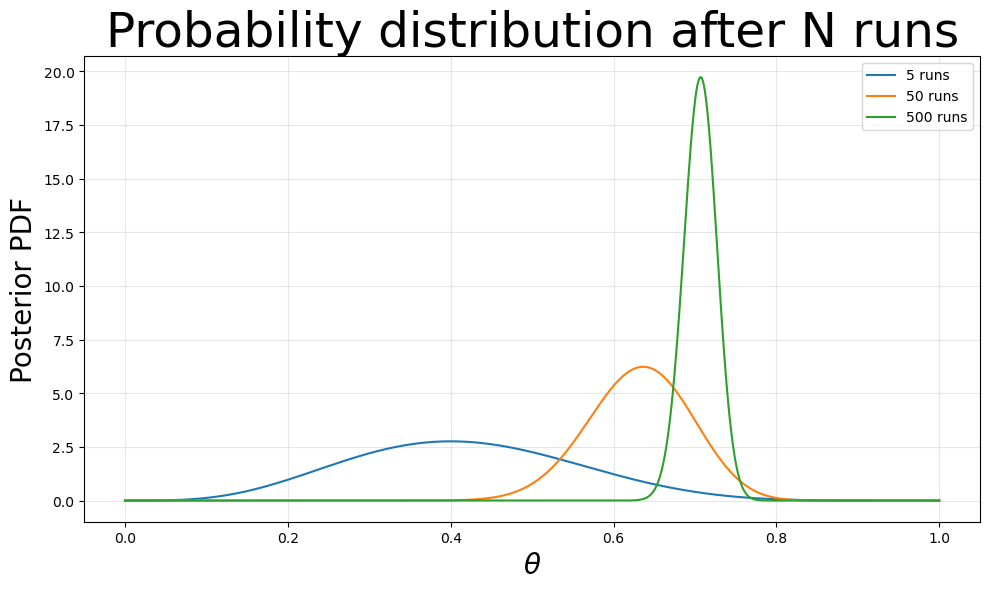

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(theta_vals,ppdf(prior_func,new_run(5),like_func,theta_vals), label = f'5 runs')
plt.plot(theta_vals,ppdf(prior_func,new_run(50),like_func,theta_vals), label = f'50 runs')
plt.plot(theta_vals,ppdf(prior_func,new_run(500),like_func,theta_vals), label = f'500 runs')
plt.xlabel(r'$\theta$', fontsize = 20)
plt.ylabel('Posterior PDF', fontsize = 20)
plt.title(f'Probability distribution after N runs',fontsize = 35)
plt.grid(True, which='both', alpha=0.3)
plt.legend()

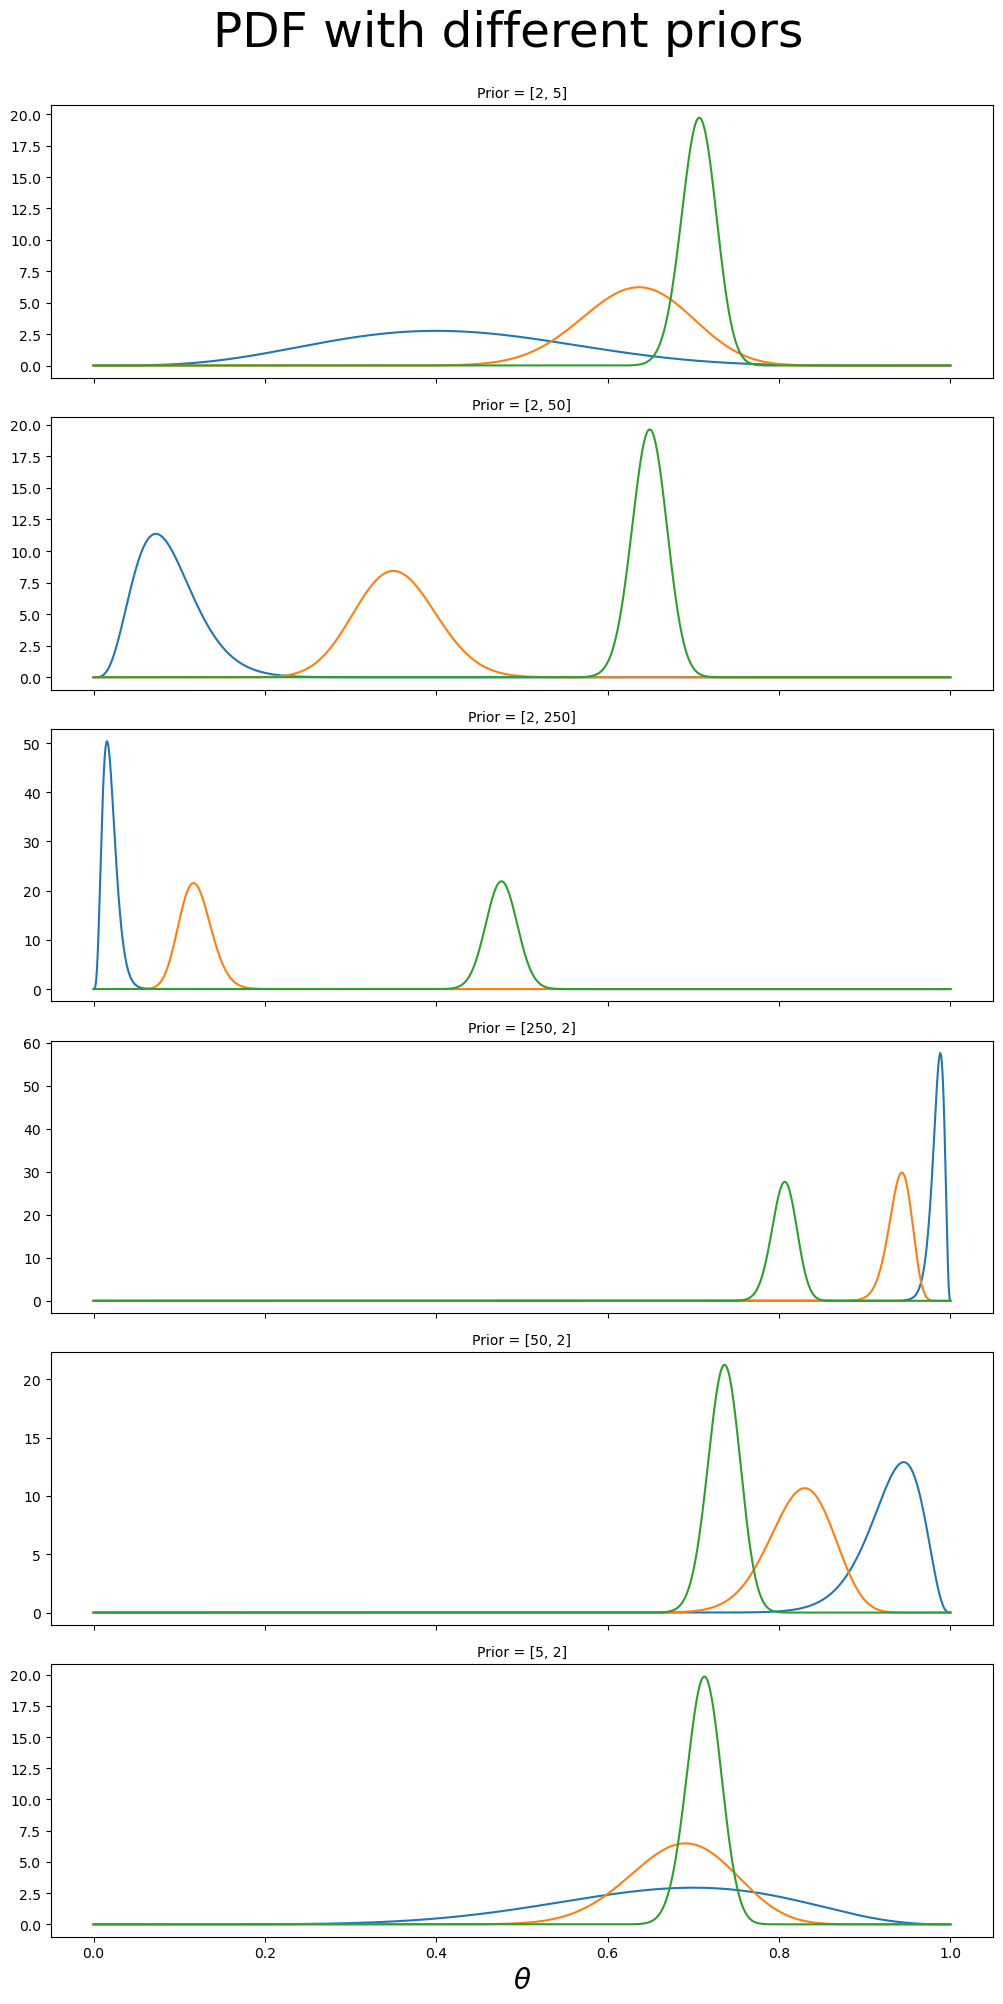

In [45]:
prior_ini_l = [[2,5], [2,50],[2,250],[250,2],[50,2],[5,2]]
fig, axes = plt.subplots(6, 1, figsize=(10, 20), sharex=True)

for ax, prior_ini in zip(axes, prior_ini_l):
    ax.plot(theta_vals,ppdf(prior_func,new_run(5),like_func,theta_vals, prior_ini), label = f'5 runs')
    ax.plot(theta_vals,ppdf(prior_func,new_run(50),like_func,theta_vals,prior_ini), label = f'50 runs')
    ax.plot(theta_vals,ppdf(prior_func,new_run(500),like_func,theta_vals,prior_ini), label = f'500 runs')
    ax.set_title(f'Prior = {prior_ini}',fontsize = 10)
axes[-1].set_xlabel(r'$\theta$', fontsize = 20)

plt.suptitle('PDF with different priors', y= 1, fontsize = 35)
plt.tight_layout()
plt.show()

In [76]:
def pi_data(N = 100):
    x = np.random.random(N)
    y = np.random.random(N)
    inside = (x**2 + y**2) <= 1
    n_inside = np.sum(inside)
    data = [n_inside, N- n_inside]
    return data

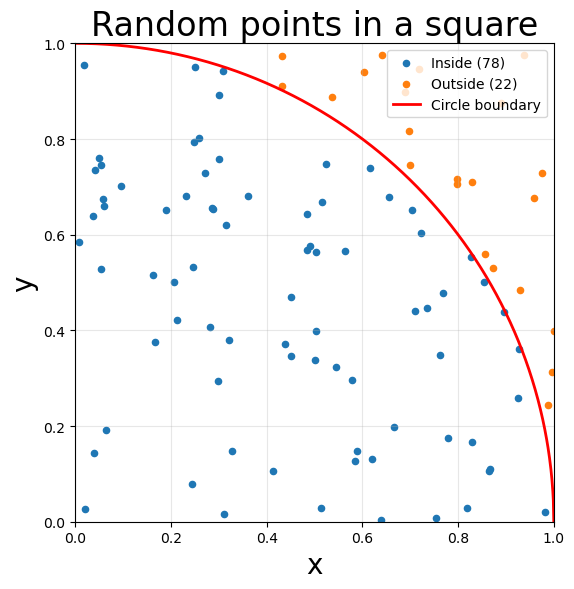

In [100]:
N = 100
x = np.random.random(N)
y = np.random.random(N)

inside = (x**2 + y**2) <= 1
n_inside = np.sum(inside)
data = [n_inside, N- n_inside]
points = [x,y]
plt.figure(figsize=(10, 6))

x_vals = np.linspace(0,1,1000)
plt.scatter(x[inside], y[inside], s=20, label=f'Inside ({n_inside})')
plt.scatter(x[~inside], y[~inside], s=20, label=f'Outside ({N-n_inside})')
plt.plot(x_vals,np.sqrt(1-x_vals**2), linewidth=2, color = "red", label = "Circle boundary")


plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.title('Random points in a square', fontsize=24)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()


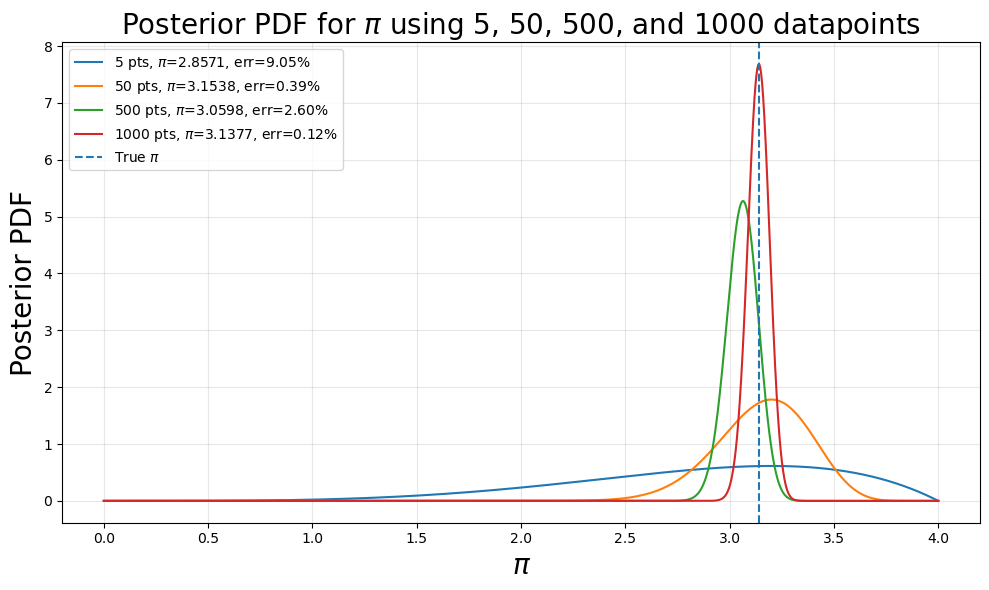

In [111]:
plt.figure(figsize=(10, 6))

theta_vals = np.linspace(1e-6, 1 - 1e-6, 5000)
data_dict = {N: pi_data(N) for N in [5, 50, 500, 1000]}

for N in [5, 50, 500, 1000]:
    data = data_dict[N]
    post_theta = ppdf(prior_func, data, like_func, theta_vals, [1, 1])

    #relative error 
    theta_mean = np.trapezoid(theta_vals * post_theta, theta_vals)
    pi_est = 4 * theta_mean
    rel_err = abs(pi_est - np.pi) / np.pi

    pi_vals = 4 * theta_vals
    post_pi = post_theta / 4
    plt.plot(pi_vals, post_pi, label=rf'{N} pts, $\pi$={pi_est:.4f}, err={rel_err:.2%}')

plt.axvline(np.pi, linestyle='--', label=r'True $\pi$')
plt.xlabel(r'$\pi$', fontsize=20)
plt.ylabel('Posterior PDF', fontsize=20)
plt.title(r'Posterior PDF for $\pi$ using 5, 50, 500, and 1000 datapoints', fontsize=20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

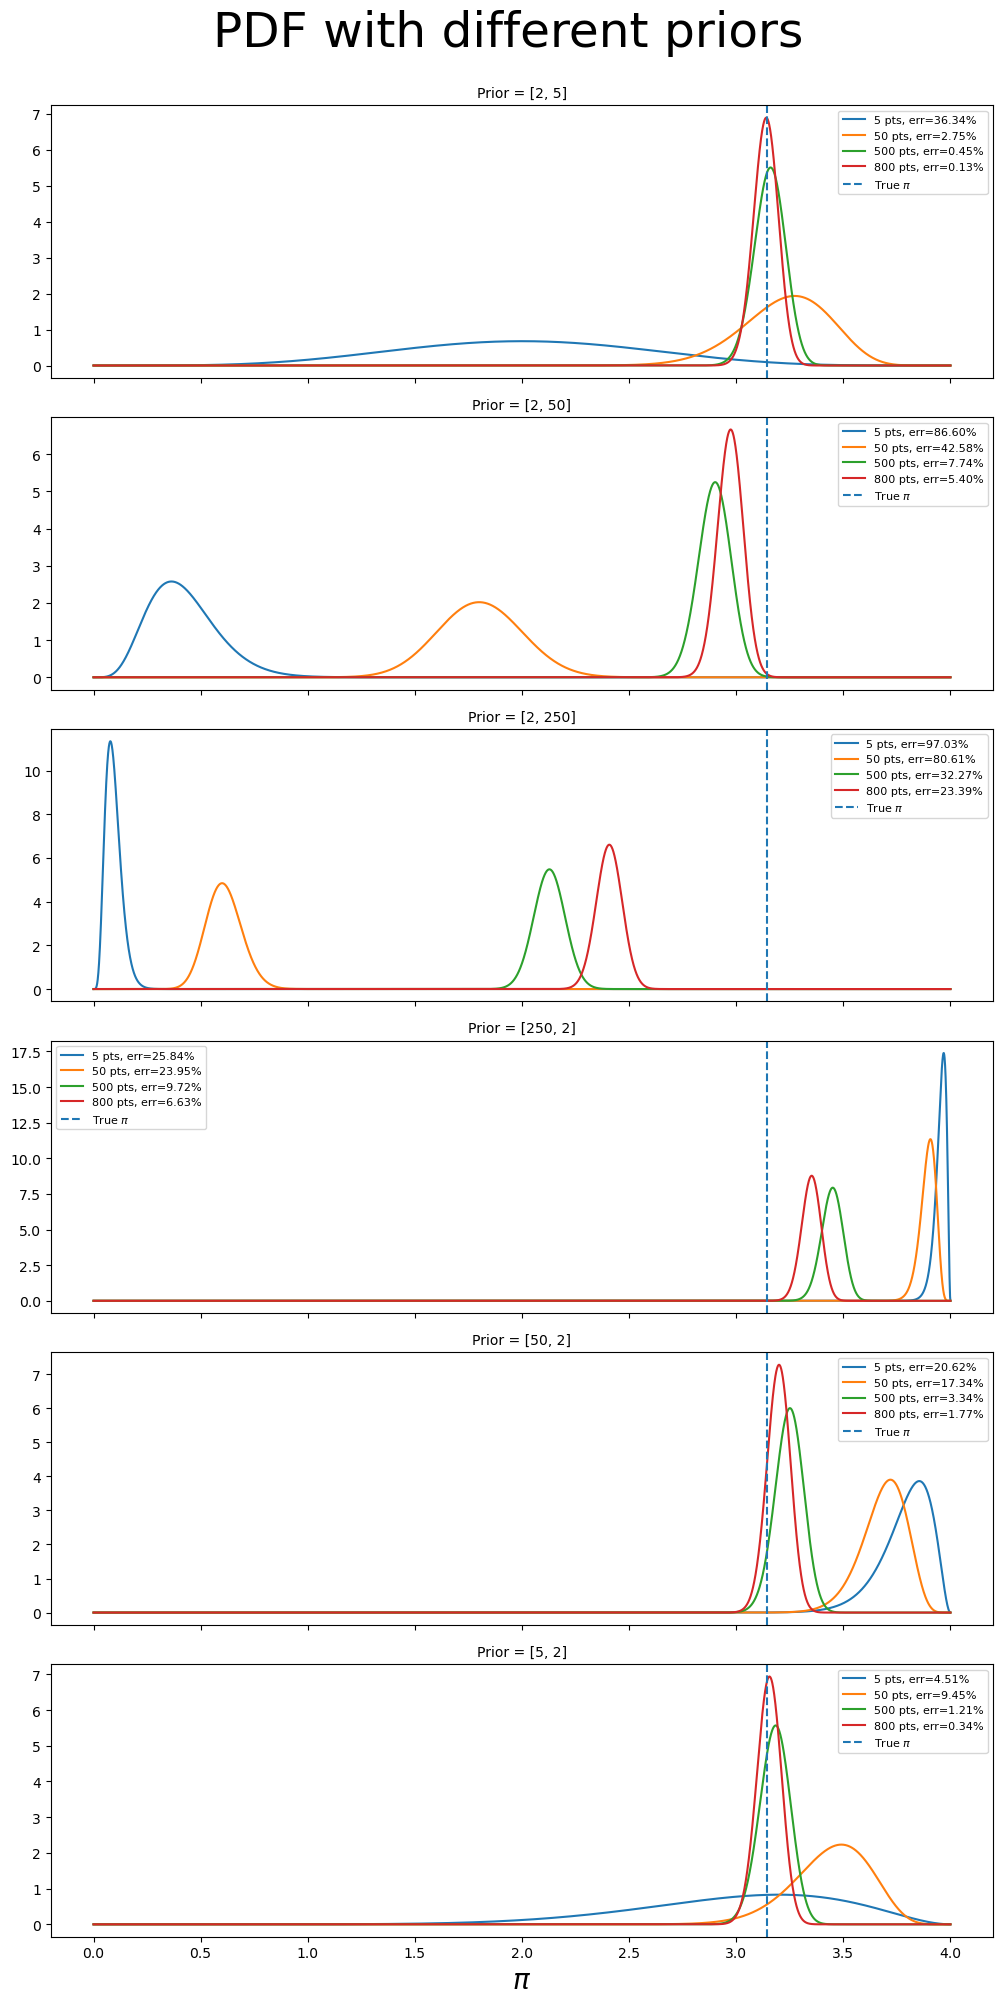

In [103]:
prior_ini_l = [[2,5], [2,50], [2,250], [250,2], [50,2], [5,2]]
fig, axes = plt.subplots(6, 1, figsize=(10, 20), sharex=True)

data_dict = {N: pi_data(N) for N in [5, 50, 500, 800]}

for ax, prior_ini in zip(axes, prior_ini_l):
    for N in [5, 50, 500, 800]:
        data = data_dict[N]
        post_theta = ppdf(prior_func, data, like_func, theta_vals, prior_ini)

        #relative error
        theta_mean = np.trapezoid(theta_vals * post_theta, theta_vals)
        pi_est = 4 * theta_mean
        rel_err = abs(pi_est - np.pi) / np.pi

        pi_vals = 4 * theta_vals
        post_pi = post_theta / 4

        ax.plot(pi_vals, post_pi, label=f'{N} pts, err={rel_err:.2%}')

    ax.set_title(f'Prior = {prior_ini}', fontsize=10)
    ax.axvline(np.pi, linestyle='--', label=r'True $\pi$')
    ax.legend(fontsize=8)

axes[-1].set_xlabel(r'$\pi$', fontsize=20)
plt.suptitle('PDF with different priors', y=1, fontsize=35)
plt.tight_layout()
plt.show()